
# MFE 230GA — Equity Market H1- 
group project by Reza, Elias, Thomas, Paraj, and Coco



### Data files
The notebook uses:
- `Emissions_FF_Industry.csv` — emissions intensity by Fama–French industry.
- `FF_49_Returns.csv` — monthly value-weighted industry returns plus Fama–French factors.

The code also accepts filenames ending in `(1)` or `(2)` in case the files were downloaded more than once.

For Question 4, the sample begins in **January 1970**, as required by the assignment.



## Setup

The following cell imports the packages, finds the two CSV files, loads the data, and converts the `YYYYMM` date variable into a proper monthly date.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

BASE = Path.cwd()

def find_file(names):
    for name in names:
        path = BASE / name
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find any of these files:\n" + "\n".join(names)
    )

EMISSIONS_FILE = find_file([
    "Emissions_FF_Industry.csv",
    "Emissions_FF_Industry(1).csv",
    "Emissions_FF_Industry(2).csv",
])

RETURNS_FILE = find_file([
    "FF_49_Returns.csv",
    "FF_49_Returns(1).csv",
    "FF_49_Returns(2).csv",
])

emissions = pd.read_csv(EMISSIONS_FILE)
returns = pd.read_csv(RETURNS_FILE)

returns["date"] = pd.to_datetime(
    returns["yymm"].astype(str),
    format="%Y%m"
)

print("Emissions file:", EMISSIONS_FILE.name)
print("Returns file:  ", RETURNS_FILE.name)
print(
    "Sample:",
    returns["date"].min().strftime("%B %Y"),
    "to",
    returns["date"].max().strftime("%B %Y")
)
print("Monthly observations:", len(returns))


Emissions file: Emissions_FF_Industry.csv
Returns file:   FF_49_Returns.csv
Sample: January 1970 to July 2022
Monthly observations: 631



# Q 2

### Question
Assuming that active returns are uncorrelated, estimate the **minimum active risk** achievable with a 20-stock portfolio relative to the S&P 500. Each stock has active risk of 25%, and the S&P 500 is assumed to be equally weighted. Also discuss what happens if the true capitalization weighting of the index is used.

### Approach
With an equal-weighted 500-stock benchmark,

\[$
w_B=\frac{1}{500}.$
\]

If the 20 selected stocks are equally weighted,

\[$
w_P=\frac{1}{20}.$
\]

The active weight of each selected stock is

\[$
\frac{1}{20}-\frac{1}{500},$
\]

while each of the other 480 stocks has active weight

\[$
-\frac{1}{500}.%
\]

Because active returns are assumed to be uncorrelated, active variance is the sum of squared active weights multiplied by the individual active variance:

\[$
\psi_P^2
=
(0.25)^2
\left[
20\left(\frac{1}{20}-\frac{1}{500}\right)^2
+
480\left(\frac{1}{500}\right)^2
\right].$
\]

This simplifies to

\[$
\psi_P
=
25\%\sqrt{\frac{1}{20}-\frac{1}{500}}.$
\]


In [2]:

# Question 2 calculation

N_benchmark = 500
N_portfolio = 20
stock_active_risk = 0.25

w_benchmark = 1 / N_benchmark
w_portfolio = 1 / N_portfolio

active_weight_held = w_portfolio - w_benchmark
active_weight_not_held = -w_benchmark

active_variance = (
    stock_active_risk**2
    * (
        N_portfolio * active_weight_held**2
        + (N_benchmark - N_portfolio) * active_weight_not_held**2
    )
)

active_risk = np.sqrt(active_variance)

print(f"Benchmark weight per stock = {w_benchmark:.4f}")
print(f"Portfolio weight per stock = {w_portfolio:.4f}")
print(f"Active weight, held stock  = {active_weight_held:.4f}")
print(f"Active weight, other stock = {active_weight_not_held:.4f}")
print(f"\nMinimum active risk = {100 * active_risk:.2f}%")

print(
    "\nInterpretation: With the actual capitalization-weighted S&P 500, "
    "the minimum active risk should generally decrease because a carefully "
    "chosen 20-stock portfolio can hold the largest benchmark names, which "
    "represent a much larger fraction of a cap-weighted index."
)


Benchmark weight per stock = 0.0020
Portfolio weight per stock = 0.0500
Active weight, held stock  = 0.0480
Active weight, other stock = -0.0020

Minimum active risk = 5.48%

Interpretation: With the actual capitalization-weighted S&P 500, the minimum active risk should generally decrease because a carefully chosen 20-stock portfolio can hold the largest benchmark names, which represent a much larger fraction of a cap-weighted index.



# Q 3

### Question
Fischer runs a **long-only** equity strategy following 500 stocks per quarter and has an information coefficient of \(0.05\). Myron has an information coefficient of \(0.08\) and plans to invest **long-short**. How many independent asset classes must Myron invest in each quarter to match Fischer's information ratio?

### Approach
Using the Fundamental Law of Active Management,

\[$
IR = IC\sqrt{BR},$
\]

where \(IC\) is the information coefficient and \(BR\) is breadth.

For Fischer,

\[$
IR_F = 0.05\sqrt{500}.$
\]

For Myron,

\[$
IR_M = 0.08\sqrt{N}.$
\]

Set the two information ratios equal and solve for \(N\):

\[$
0.08\sqrt{N}=0.05\sqrt{500},$
\]

so

\[$
N=500\left(\frac{0.05}{0.08}\right)^2.$
\]

The calculation below uses the standard Fundamental Law because the question does not provide a transfer coefficient for Fischer's long-only constraint.


In [3]:

# Question 3 calculation

IC_Fischer = 0.05
breadth_Fischer = 500
IC_Myron = 0.08

IR_Fischer = IC_Fischer * np.sqrt(breadth_Fischer)

required_breadth = (
    breadth_Fischer
    * (IC_Fischer / IC_Myron) ** 2
)

required_breadth_integer = int(np.ceil(required_breadth))

print(f"Fischer information ratio = {IR_Fischer:.4f}")
print(f"Required Myron breadth     = {required_breadth:.4f}")
print(
    f"\nMyron needs approximately "
    f"{required_breadth_integer} independent asset classes per quarter."
)


Fischer information ratio = 1.1180
Required Myron breadth     = 195.3125

Myron needs approximately 196 independent asset classes per quarter.



# Q 4(a)

### Question
Use the emissions-intensity file to identify the **five highest-emitting** and **five lowest-emitting** Fama–French industries. Then summarize the performance of those industries using monthly value-weighted returns beginning in January 1970.

### Approach
I rank industries by `emissions_intensity`. For each selected industry, I report:

- compound annual growth rate (CAGR),
- annualized volatility,
- annualized Sharpe ratio,
- ending value of a \$1 investment.

The emissions file contains a single cross-sectional emissions-intensity measure for each industry, so it identifies the ranking used in the homework but does **not** provide a time series of emissions rankings.


In [4]:

# Helper function used in Questions 4 and 5

returns["RF_dec"] = returns["rf"] / 100

def performance_stats(r, rf=None):
    r = r.dropna()
    years = len(r) / 12

    ending_value = (1 + r).prod()
    cagr = ending_value ** (1 / years) - 1
    annualized_vol = r.std(ddof=1) * np.sqrt(12)

    if rf is not None:
        rf = rf.loc[r.index]
        excess = r - rf
    else:
        # For the zero-cost Green long-short portfolio
        excess = r

    sharpe = (
        excess.mean()
        / excess.std(ddof=1)
        * np.sqrt(12)
    )

    return {
        "Ending Value": ending_value,
        "CAGR": cagr,
        "Annualized Vol": annualized_vol,
        "Sharpe": sharpe,
    }


In [5]:

# Identify highest- and lowest-emitting industries

lowest_5 = emissions.nsmallest(5, "emissions_intensity").copy()
highest_5 = emissions.nlargest(5, "emissions_intensity").copy()

# Return columns are lowercase in FF_49_Returns.csv
lowest_5["return_col"] = lowest_5["ff"].str.lower()
highest_5["return_col"] = highest_5["ff"].str.lower()

low_cols = lowest_5["return_col"].tolist()
high_cols = highest_5["return_col"].tolist()

print("Five lowest-emitting industries:")
display(lowest_5[["ff", "emissions_intensity"]])

print("Five highest-emitting industries:")
display(highest_5[["ff", "emissions_intensity"]])


Five lowest-emitting industries:


,ff,emissions_intensity
0,Fun,0.000540
1,RlEst,0.004648
2,Drugs,0.004700
3,Telcm,0.005654
4,Fin,0.009137


Five highest-emitting industries:


,ff,emissions_intensity
40,Util,3.264277
39,Ships,1.018529
38,Aero,0.530780
37,Steel,0.403085
36,BldMt,0.365274


In [6]:

# Individual industry performance

industry_results = []

for group_name, industry_data in [
    ("Low", lowest_5),
    ("High", highest_5),
]:
    for _, row in industry_data.iterrows():
        r = returns[row["return_col"]] / 100
        stats = performance_stats(r, returns["RF_dec"])

        industry_results.append({
            "Group": group_name,
            "Industry": row["ff"],
            "Emissions Intensity": row["emissions_intensity"],
            "CAGR": stats["CAGR"],
            "Annualized Vol": stats["Annualized Vol"],
            "Sharpe": stats["Sharpe"],
            "Ending Value": stats["Ending Value"],
        })

industry_performance = pd.DataFrame(industry_results)

industry_display = industry_performance.copy()
industry_display["CAGR"] *= 100
industry_display["Annualized Vol"] *= 100

print("Performance of the selected industries:")
display(
    industry_display[
        [
            "Group",
            "Industry",
            "Emissions Intensity",
            "CAGR",
            "Annualized Vol",
            "Sharpe",
            "Ending Value",
        ]
    ].round(3)
)


Performance of the selected industries:


,Group,Industry,Emissions Intensity,CAGR,Annualized Vol,Sharpe,Ending Value
0,Low,Fun,0.001,11.799,27.275,0.390,352.397
1,Low,RlEst,0.005,4.282,26.630,0.127,9.069
2,Low,Drugs,0.005,11.866,17.325,0.485,363.741
3,Low,Telcm,0.006,10.006,16.542,0.400,150.567
4,Low,Fin,0.009,11.643,21.933,0.417,327.475
5,High,Util,3.264,10.549,14.237,0.474,195.121
6,High,Ships,1.019,9.955,25.578,0.330,146.973
7,High,Aero,0.531,12.094,23.882,0.420,404.793
8,High,Steel,0.403,6.296,27.585,0.204,24.792
9,High,BldMt,0.365,10.405,22.176,0.363,182.169



# Q 4(b)

### Question
Form an **equal-weighted portfolio** of the five highest-emitting industries and an equal-weighted portfolio of the five lowest-emitting industries. Plot the cumulative returns of both portfolios and of a ``Green'' strategy that is:

\[$
\text{Green} = \text{Low Emissions} - \text{High Emissions}.$
\]

### Portfolio construction
The monthly low-emissions portfolio return is

\[$
R_{Low,t}
=
\frac{1}{5}
\sum_{i\in Low}R_{i,t},$
\]

and the high-emissions portfolio is

\[$
R_{High,t}
=
\frac{1}{5}
\sum_{i\in High}R_{i,t}.$
\]

The long-short Green return is

\[$
R_{Green,t}=R_{Low,t}-R_{High,t}.$
\]

For each strategy, cumulative wealth beginning from \$1 is

\[$
W_t=\prod_{s=1}^{t}(1+R_s).$
\]


In [7]:

# Construct equal-weighted portfolios

returns["Low"] = returns[low_cols].mean(axis=1) / 100
returns["High"] = returns[high_cols].mean(axis=1) / 100
returns["Green"] = returns["Low"] - returns["High"]

low_stats = performance_stats(returns["Low"], returns["RF_dec"])
high_stats = performance_stats(returns["High"], returns["RF_dec"])
green_stats = performance_stats(returns["Green"])

portfolio_stats = pd.DataFrame({
    "Low": low_stats,
    "High": high_stats,
    "Green": green_stats,
}).T

portfolio_display = portfolio_stats.copy()
portfolio_display["CAGR"] *= 100
portfolio_display["Annualized Vol"] *= 100

print("Full-sample portfolio performance:")
display(portfolio_display.round(3))


Full-sample portfolio performance:


,Ending Value,CAGR,Annualized Vol,Sharpe
Low,221.345,10.815,18.174,0.420
High,225.428,10.853,18.779,0.414
Green,0.725,-0.609,9.580,-0.016


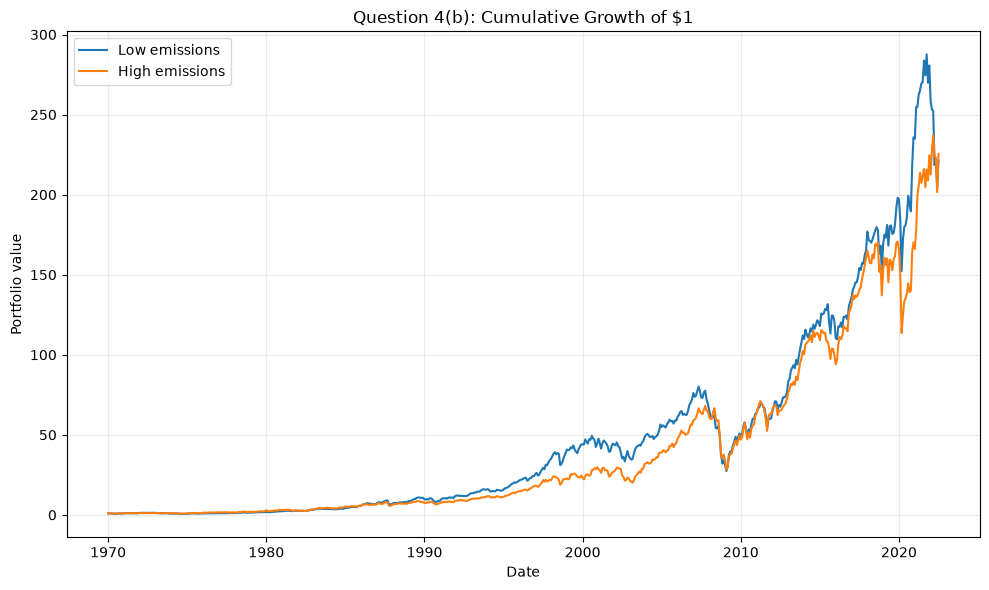

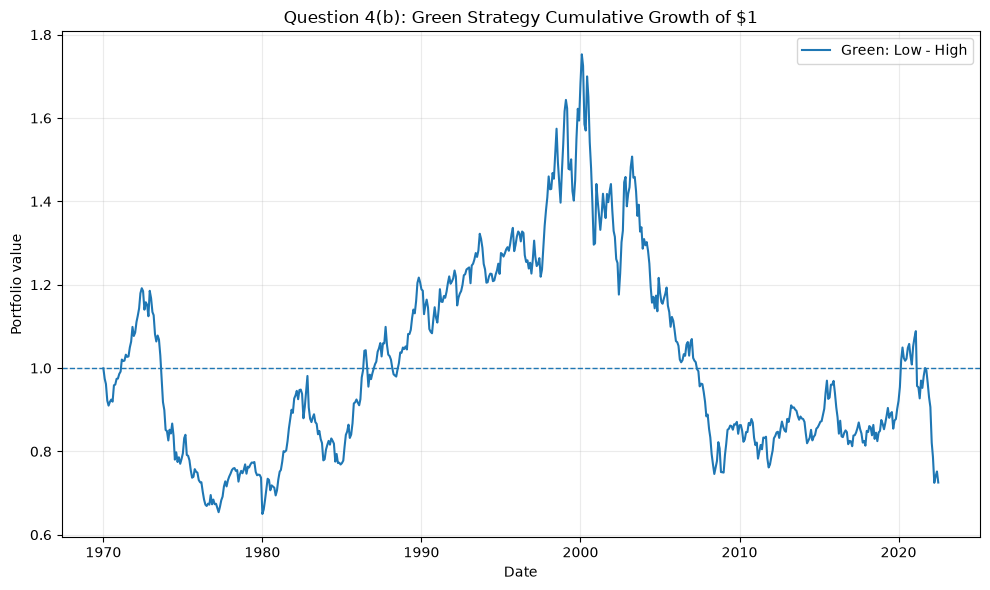

Low-emissions ending value:  $221.345
High-emissions ending value: $225.428
Green ending value:          $0.725


In [8]:

# Cumulative wealth series

returns["Cum_Low"] = (1 + returns["Low"]).cumprod()
returns["Cum_High"] = (1 + returns["High"]).cumprod()
returns["Cum_Green"] = (1 + returns["Green"]).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(returns["date"], returns["Cum_Low"], label="Low emissions")
plt.plot(returns["date"], returns["Cum_High"], label="High emissions")
plt.title("Question 4(b): Cumulative Growth of $1")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("q4b_high_low_cumulative.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(returns["date"], returns["Cum_Green"], label="Green: Low - High")
plt.axhline(1.0, linewidth=1, linestyle="--")
plt.title("Question 4(b): Green Strategy Cumulative Growth of $1")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("q4b_green_cumulative.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Low-emissions ending value:  ${returns['Cum_Low'].iloc[-1]:.3f}")
print(f"High-emissions ending value: ${returns['Cum_High'].iloc[-1]:.3f}")
print(f"Green ending value:          ${returns['Cum_Green'].iloc[-1]:.3f}")



## Q 4(b) — Interpretation

Over the full sample, the High- and Low-emissions portfolios have very similar cumulative performance. The Green Low-minus-High portfolio is much more regime dependent: it performs well in some earlier periods, especially before and around 2000, but much of that relative gain is later reversed.

This suggests that simply buying the five lowest-emitting industries and shorting the five highest-emitting industries does not generate a stable positive return over the entire sample.



# Q 4(c)

### Question
Estimate and analyze factor loadings for the **High**, **Low**, and **Green Low-minus-High** portfolios using the Fama–French three factors:

- Market excess return (MKT),
- Size (SMB),
- Value (HML).

The assignment asks for three periods:

1. Full sample,
2. January 2010 to the end of the data,
3. Most recent 13 months.

It also asks what happened to the **HML loading** and why.

### Regression specification

For the Low and High portfolios,

\[$
R_{p,t}-R_{f,t}
=
\alpha_p
+
\beta_{MKT,p}MKT_t
+
\beta_{SMB,p}SMB_t
+
\beta_{HML,p}HML_t
+
\epsilon_{p,t}.$
\]

For the zero-cost Green strategy,

\[
$R_{Green,t}
=
\alpha_G
+
\beta_{MKT,G}MKT_t
+
\beta_{SMB,G}SMB_t
+
\beta_{HML,G}HML_t
+
\epsilon_{G,t}.$
\]


In [9]:

# Prepare factor returns in decimal form

returns["MKT"] = returns["mktrf"] / 100
returns["SMB"] = returns["smb"] / 100
returns["HML"] = returns["hml"] / 100

def factor_regression(data, portfolio):
    if portfolio in ["Low", "High"]:
        y = data[portfolio] - data["RF_dec"]
    else:
        y = data["Green"]

    X = sm.add_constant(data[["MKT", "SMB", "HML"]])
    return sm.OLS(y, X).fit()

periods = {
    "Full Sample": returns.copy(),
    "2010-Present": returns[returns["date"] >= "2010-01-01"].copy(),
    "Last 13 Months": returns.tail(13).copy(),
}

regression_results = []

for period_name, data in periods.items():
    for portfolio in ["Low", "High", "Green"]:
        model = factor_regression(data, portfolio)

        regression_results.append({
            "Period": period_name,
            "Portfolio": portfolio,
            "Alpha": model.params["const"],
            "MKT": model.params["MKT"],
            "SMB": model.params["SMB"],
            "HML": model.params["HML"],
            "Alpha t-stat": model.tvalues["const"],
            "MKT t-stat": model.tvalues["MKT"],
            "SMB t-stat": model.tvalues["SMB"],
            "HML t-stat": model.tvalues["HML"],
            "R2": model.rsquared,
        })

regression_table = pd.DataFrame(regression_results)

regression_display = regression_table[
    [
        "Period",
        "Portfolio",
        "Alpha",
        "MKT",
        "SMB",
        "HML",
        "HML t-stat",
        "R2",
    ]
].copy()

regression_display["Alpha"] *= 100
regression_display = regression_display.rename(
    columns={"Alpha": "Monthly Alpha (%)"}
)

display(regression_display.round(3))


,Period,Portfolio,Monthly Alpha (%),MKT,SMB,HML,HML t-stat,R2
0,Full Sample,Low,-0.063,1.066,0.174,0.171,7.600,0.898
1,Full Sample,High,-0.132,1.085,0.158,0.404,14.026,0.845
2,Full Sample,Green,0.069,-0.019,0.017,-0.232,-6.453,0.066
3,2010-Present,Low,-0.090,1.071,0.202,0.052,1.381,0.918
4,2010-Present,High,-0.032,1.112,0.250,0.399,7.585,0.872
5,2010-Present,Green,-0.057,-0.041,-0.048,-0.347,-5.464,0.181
6,Last 13 Months,Low,-0.755,1.092,0.427,0.195,1.177,0.899
7,Last 13 Months,High,1.382,1.060,0.671,0.319,1.380,0.807
8,Last 13 Months,Green,-2.137,0.032,-0.245,-0.124,-0.399,0.033


In [10]:

# Focus on the HML drift of the Green strategy

green_results = regression_table[
    regression_table["Portfolio"] == "Green"
].copy()

display(
    green_results[
        ["Period", "MKT", "SMB", "HML", "HML t-stat", "R2"]
    ].round(3)
)

full_hml = green_results.loc[
    green_results["Period"] == "Full Sample", "HML"
].iloc[0]

post2010_hml = green_results.loc[
    green_results["Period"] == "2010-Present", "HML"
].iloc[0]

recent_hml = green_results.loc[
    green_results["Period"] == "Last 13 Months", "HML"
].iloc[0]

print(
    f"Green HML progression: "
    f"{full_hml:.3f} -> {post2010_hml:.3f} -> {recent_hml:.3f}"
)


,Period,MKT,SMB,HML,HML t-stat,R2
2,Full Sample,-0.019,0.017,-0.232,-6.453,0.066
5,2010-Present,-0.041,-0.048,-0.347,-5.464,0.181
8,Last 13 Months,0.032,-0.245,-0.124,-0.399,0.033


Green HML progression: -0.232 -> -0.347 -> -0.124



## Q 4(c) — Interpretation

The main result is that the Green Low-minus-High portfolio has very little market exposure over the longer samples, but it has a meaningful **negative HML loading**.

Using the supplied data, the Green HML loading is approximately

\[$
-0.232
\rightarrow
-0.347
\rightarrow
-0.124$
\]

for the full sample, 2010–present, and the last 13 months.

The negative HML exposure is particularly strong after 2010. The reason is visible by comparing the two sides of the strategy: the high-emissions portfolio has a much stronger positive value loading than the low-emissions portfolio. Therefore,

\[
Low-High
\]

also creates an implicit **short-value / long-growth** exposure.

The last-13-month HML estimate is closer to zero, but that regression uses only 13 observations, so it should be interpreted cautiously.



# Q 5(a)

### Question
Before asking ChatGPT for strategy ideas, provide a concise **2–3 bullet empirical summary** of the results from Question 4.

The assignment asks the summary to include:

1. The five highest- and lowest-emitting industries and whether the rankings are stable over time.
2. Performance highlights for the High, Low, and Green portfolios, including CAGR, annualized volatility, Sharpe ratio, and any recent reversal or regime change.
3. Notable MKT, SMB, and HML loadings over the full sample, 2010–present, and the last 13 months, with particular attention to HML drift.

The code below generates all of the numerical inputs needed for those bullets.


In [11]:

# Question 5(a): collect the key empirical facts

last13 = returns.tail(13)

last13_results = {
    portfolio: (1 + last13[portfolio]).prod() - 1
    for portfolio in ["Low", "High", "Green"]
}

low_names = ", ".join(lowest_5["ff"].tolist())
high_names = ", ".join(highest_5["ff"].tolist())

print("QUESTION 5(a) CONTEXT SUMMARY")
print("=" * 75)

print("\n1) Emissions ranking")
print("Lowest emitters :", low_names)
print("Highest emitters:", high_names)
print(
    "Ranking stability cannot be directly tested because the provided "
    "emissions file contains one cross-sectional emissions-intensity measure "
    "rather than a time series of emissions rankings."
)

print("\n2) Performance")
print(
    f"Low: CAGR={100*low_stats['CAGR']:.2f}%, "
    f"Vol={100*low_stats['Annualized Vol']:.2f}%, "
    f"Sharpe={low_stats['Sharpe']:.2f}"
)
print(
    f"High: CAGR={100*high_stats['CAGR']:.2f}%, "
    f"Vol={100*high_stats['Annualized Vol']:.2f}%, "
    f"Sharpe={high_stats['Sharpe']:.2f}"
)
print(
    f"Green: CAGR={100*green_stats['CAGR']:.2f}%, "
    f"Vol={100*green_stats['Annualized Vol']:.2f}%, "
    f"Sharpe={green_stats['Sharpe']:.2f}"
)
print(
    f"Last 13 months: "
    f"Low={100*last13_results['Low']:.2f}%, "
    f"High={100*last13_results['High']:.2f}%, "
    f"Green={100*last13_results['Green']:.2f}%"
)

print("\n3) Green factor exposures")
for _, row in green_results.iterrows():
    print(
        f"{row['Period']}: "
        f"MKT={row['MKT']:.3f}, "
        f"SMB={row['SMB']:.3f}, "
        f"HML={row['HML']:.3f}, "
        f"HML t-stat={row['HML t-stat']:.2f}"
    )

print(
    "\nInterpretation: the Green strategy is not factor-neutral. "
    "Its most important unintended exposure is negative HML, especially "
    "after 2010, because the high-emissions industries are more value-loaded."
)


QUESTION 5(a) CONTEXT SUMMARY

1) Emissions ranking
Lowest emitters : Fun, RlEst, Drugs, Telcm, Fin
Highest emitters: Util, Ships, Aero, Steel, BldMt
Ranking stability cannot be directly tested because the provided emissions file contains one cross-sectional emissions-intensity measure rather than a time series of emissions rankings.

2) Performance
Low: CAGR=10.81%, Vol=18.17%, Sharpe=0.42
High: CAGR=10.85%, Vol=18.78%, Sharpe=0.41
Green: CAGR=-0.61%, Vol=9.58%, Sharpe=-0.02
Last 13 months: Low=-17.85%, High=8.70%, Green=-25.22%

3) Green factor exposures
Full Sample: MKT=-0.019, SMB=0.017, HML=-0.232, HML t-stat=-6.45
2010-Present: MKT=-0.041, SMB=-0.048, HML=-0.347, HML t-stat=-5.46
Last 13 Months: MKT=0.032, SMB=-0.245, HML=-0.124, HML t-stat=-0.40

Interpretation: the Green strategy is not factor-neutral. Its most important unintended exposure is negative HML, especially after 2010, because the high-emissions industries are more value-loaded.



## Q 5(a) — Humanized write-up

- **Emissions ranking.** The five lowest-emitting industries are **Fun, RlEst, Drugs, Telcm, and Fin**, while the five highest-emitting industries are **Util, Ships, Aero, Steel, and BldMt**. The provided emissions file contains one cross-sectional emissions-intensity measure rather than a historical time series, so I can identify the ranking used for the homework but cannot directly test whether the ranking is stable over time.

- **Performance.** From January 1970 through July 2022, the Low and High portfolios have very similar long-run performance. The Low portfolio has a CAGR of about **10.81%**, annualized volatility of **18.17%**, and a Sharpe ratio of about **0.42**. The High portfolio has a CAGR of about **10.85%**, volatility of **18.78%**, and a Sharpe ratio of about **0.41–0.42**. The Green Low-minus-High strategy has a CAGR of roughly **−0.61%**, volatility of about **9.58%**, and a Sharpe ratio close to zero. The Green strategy is strongly regime dependent; in the last 13 months, Low lost about **17.9%**, High gained about **8.7%**, and Green lost about **25.2%**.

- **Factor exposures.** The Green strategy has very little market exposure over the longer samples but a meaningful negative HML exposure. Its HML loading moves from about **−0.232** over the full sample to **−0.347** from 2010 onward, before moving toward zero to about **−0.124** in the last 13 months. The main explanation is portfolio composition: the high-emissions basket is more strongly value-loaded, so long Low / short High also creates an implicit short-value / long-growth exposure. This means the strategy's performance should not be interpreted as a pure emissions effect without controlling for HML and the other factors.



# Optional: Save Tables

The final cell saves the main Question 4 tables to CSV files so they can be submitted or used in the written report.


In [12]:

industry_performance.to_csv(
    "q4a_industry_performance.csv",
    index=False
)

portfolio_stats.to_csv(
    "q4b_portfolio_performance.csv"
)

regression_table.to_csv(
    "q4c_factor_regressions.csv",
    index=False
)

print("Saved:")
print(" - q4a_industry_performance.csv")
print(" - q4b_portfolio_performance.csv")
print(" - q4c_factor_regressions.csv")
print(" - q4b_high_low_cumulative.png")
print(" - q4b_green_cumulative.png")


Saved:
 - q4a_industry_performance.csv
 - q4b_portfolio_performance.csv
 - q4c_factor_regressions.csv
 - q4b_high_low_cumulative.png
 - q4b_green_cumulative.png
